In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats


In [ ]:
df = pd.read_csv('day.csv')

In [ ]:
df = df[['season', 'temp', 'hum', 'windspeed', 'cnt']]

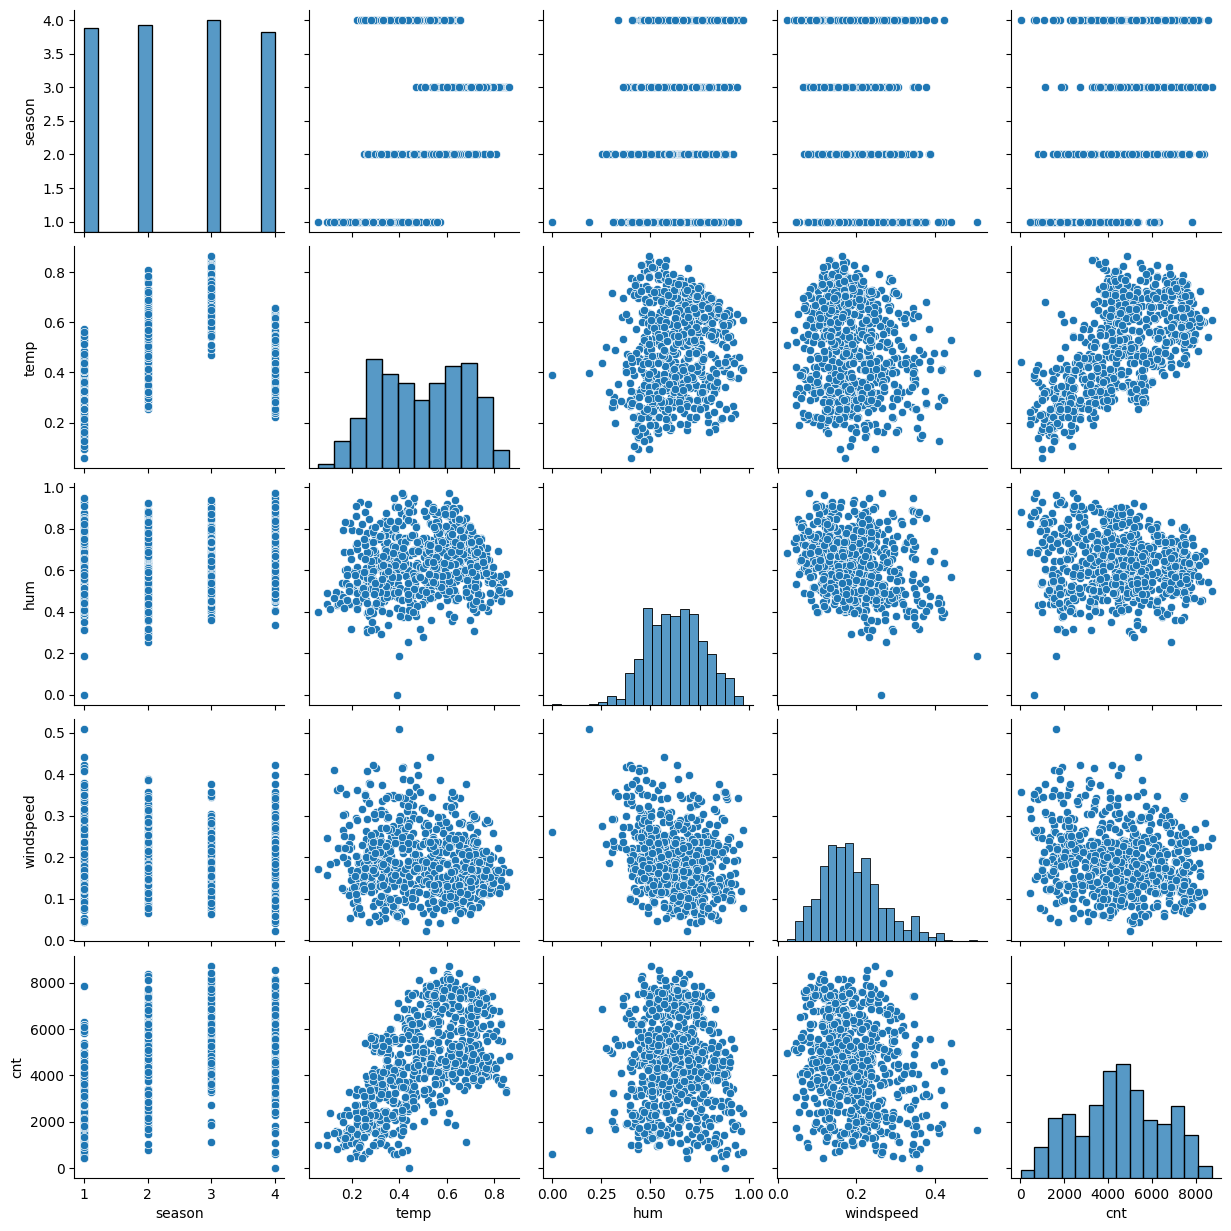

In [ ]:
sns.pairplot(df)

In [ ]:
df.corr()

,season,temp,hum,windspeed,cnt
season,1.000000,0.334315,0.205445,-0.229046,0.406100
temp,0.334315,1.000000,0.126963,-0.157944,0.627494
hum,0.205445,0.126963,1.000000,-0.248489,-0.100659
windspeed,-0.229046,-0.157944,-0.248489,1.000000,-0.234545
cnt,0.406100,0.627494,-0.100659,-0.234545,1.000000


In [ ]:
df.corr()['cnt']

,cnt
season,0.406100
temp,0.627494
hum,-0.100659
windspeed,-0.234545
cnt,1.000000


In [ ]:
df.corr()['windspeed']

,windspeed
season,-0.229046
temp,-0.157944
hum,-0.248489
windspeed,1.000000
cnt,-0.234545


In [ ]:
df.groupby(by = 'season')['cnt'].mean()

,cnt
season,
1,2604.132597
2,4992.331522
3,5644.303191
4,4728.162921


<Axes: xlabel='season', ylabel='cnt'>

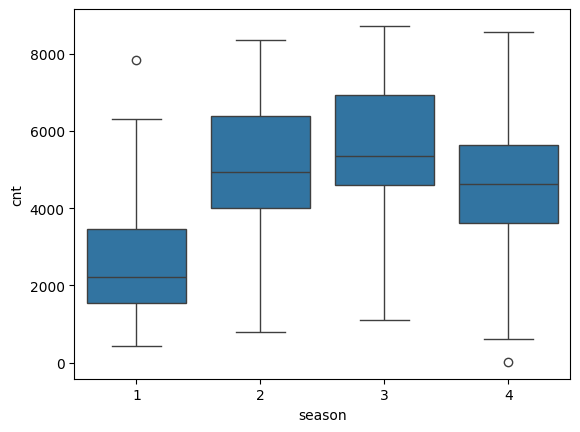

In [ ]:
sns.boxplot(x = 'season', y = 'cnt', data = df)

In [ ]:
stats.ttest_ind(df[df['season'] == 3]['cnt'], df[df['season'] == 2]['cnt'])

TtestResult(statistic=np.float64(3.976541861166125), pvalue=np.float64(8.411509811510002e-05), df=np.float64(370.0))

In [ ]:
for col in ['temp', 'hum', 'windspeed']:
  col_normalized = (df[col] - np.mean(df[col]))/np.std(df[col])
  print(col, stats.kstest(col_normalized, 'norm'))

temp KstestResult(statistic=np.float64(0.07282591241722414), pvalue=np.float64(0.0008118777412465271), statistic_location=np.float64(0.745013829060404), statistic_sign=np.int8(-1))
hum KstestResult(statistic=np.float64(0.03402247460327118), pvalue=np.float64(0.35786979689426124), statistic_location=np.float64(-0.837087677951363), statistic_sign=np.int8(1))
windspeed KstestResult(statistic=np.float64(0.06269855311461792), pvalue=np.float64(0.006101270206418192), statistic_location=np.float64(0.0057174673847248956), statistic_sign=np.int8(1))


In [ ]:
df['logwindspeed'] = np.log(df.windspeed + 1)
df['logwindspeed'] = (df['logwindspeed'] - np.mean(df['logwindspeed']))/np.std(df['logwindspeed'])
stats.kstest(df['logwindspeed'], 'norm')

KstestResult(statistic=np.float64(0.04976806588949245), pvalue=np.float64(0.051708555858933525), statistic_location=np.float64(0.03813860487259319), statistic_sign=np.int8(1))